# NN Stage 2 — long synapse regression (MLP + CNN variants)

Same splits and scenarios as `abr_wide_long_comparison_newfeats.ipynb`: **Stage 1** = wide RF noise classifier; **Stage 2** = PyTorch on **long** rows (raw `synapses` target), plus a parallel block that trains **MLP on pivoted wide** rows (same A/B/C scenarios). **No even-SPL** tables.

**Stage 1 wide RF & Stage 2 tabular:** by default `load_nn_stage2_data()` does **not** use `Slope_all`, `Slope_high4`, or `p1_latency` in either stage (Stage 1: only pivoted level-wise wide columns; Stage 2: only `amplitude`, `slope`, `distance`, `level` among numeric long fields, plus log/categorical columns). Pass `include_extra_wide_features=True` to add those three fields everywhere, matching the newfeats notebook.

**CNN (Wave I, 30 pts):** Both labs use the **same** pipeline: crop **0–8 ms**, **resample** to a fixed length **T**, then take **30 samples** centred at `p1_latency` on the uniform 0–8 ms axis (`unified_grid_wave_i_*`). **T** is either **Liberman’s** median post-crop length or **Brad’s** (`RunConfig(full_wave_ref="lib"|"brad")`); the notebook runs **both** for comparison.

**CNN (full wave, 0–8 ms):** Same crop + resample to **T**; the encoder sees the **entire** segment (no 30-pt window). Liberman full trace is on **0–17 ms**; Brad uses **`x` in ms**. Override **T** with `RunConfig(full_wave_target_len=...)` if needed.

Style follows `03_CNN.ipynb` (matplotlib / seaborn / torch upfront). **Run with working directory = `ABR2synapse`** so `../abr_data` and `../liberman_wpz` resolve.

## Load tables and splits

Run the **imports** cell below first, then **load data**.

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 100

import importlib

import utils.nn_stage2
importlib.reload(utils.nn_stage2)

from utils.nn_stage2_data import (
    FULL_WAVE_WINDOW_MS,
    LIB_FULL_WAVEFORM_MS,
    full_wave_matrix,
    load_nn_stage2_data,
    splits_for_long_stage2,
    unified_grid_wave_i_matrix,
)
from utils.nn_stage2 import (
    RunConfig,
    bb_long_s2_rows,
    bb_wide_s2_rows,
    fit_stage1_wide_rf,
    lib_long_s2_rows,
    lib_wide_s2_rows,
    long_s2_triple_nn,
    run_two_stage_long_nn,
    run_two_stage_wide_nn,
    wide_s2_triple_nn,
)

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.9.0 | cuda: False


In [2]:
data = (
    load_nn_stage2_data()
)  # include_extra_wide_features=True → newfeats Stage 1 + 2 extras
sp = splits_for_long_stage2(data)

bb_w_tr, bb_w_te = sp["bb_wide_train"], sp["bb_wide_test"]
lib_tr, lib_te = sp["lib_train"], sp["lib_test"]
bb_lt, bb_lte = sp["bb_long_train"], sp["bb_long_test"]
lib_lt, lib_lte = sp["lib_long_train"], sp["lib_long_test"]

split_summary = pd.DataFrame(
    [
        ("Brad", "wide", len(bb_w_tr), len(bb_w_te)),
        ("Brad", "long", len(bb_lt), len(bb_lte)),
        ("Liberman", "wide", len(lib_tr), len(lib_te)),
        ("Liberman", "long", len(lib_lt), len(lib_lte)),
    ],
    columns=["cohort", "format", "train_rows", "test_rows"],
)
display(split_summary)
pd.DataFrame(
    [
        {
            "Lib_full_trace_ms": LIB_FULL_WAVEFORM_MS,
            "cnn_full_window_ms": str(FULL_WAVE_WINDOW_MS),
            "median_crop_len_Brad": data.full_wave_median_len_bb,
            "median_crop_len_Lib": data.full_wave_median_len_lib,
            "target_len_resample_Lib": data.full_wave_target_len_lib,
            "target_len_resample_Brad": data.full_wave_target_len_brad,
            "default_target_len (load pref)": data.full_wave_target_len,
        }
    ]
)

,cohort,format,train_rows,test_rows
0,Brad,wide,283,77
1,Brad,long,2811,743
2,Liberman,wide,491,125
3,Liberman,long,9751,2436


,Lib_full_trace_ms,cnn_full_window_ms,median_crop_len_Brad,median_crop_len_Lib,target_len_resample_Lib,target_len_resample_Brad,default_target_len (load pref)
0,17.0,"(0.0, 8.0)",100,201,201,100,201


## Waveform length audit (within Brad vs within Liberman)

Checks whether **every long row** in a cohort shares the same sample count **before** resampling. If **uniform** after the 0–8 ms crop, you do not need a *within-cohort* length fix—only the **cross-cohort** step (`cnn_full_target_len`) may still resample one lab to match the other when medians differ.

In [3]:
import numpy as np
import pandas as pd

from utils.nn_stage2_data import crop_brad_waveform_0_8ms, crop_lib_waveform_0_8ms

bb, lib = data.brad_buran_df, data.orig_lib

orig_bb = [
    len(np.asarray(r["waveform"], dtype=float).ravel()) for _, r in bb.iterrows()
]
orig_lib = [
    len(np.asarray(r["full_waveform"], dtype=float).ravel()) for _, r in lib.iterrows()
]
crop_bb = [crop_brad_waveform_0_8ms(r).size for _, r in bb.iterrows()]
crop_lib = [crop_lib_waveform_0_8ms(r).size for _, r in lib.iterrows()]

rows = []
for label, L in [
    ("Brad — original full waveform", orig_bb),
    ("Brad — after 0–8 ms crop", crop_bb),
    ("Liberman — original full waveform", orig_lib),
    ("Liberman — after 0–8 ms crop", crop_lib),
]:
    vc = pd.Series(L).value_counts().sort_index()
    rows.append(
        {
            "stage": label,
            "n_rows": len(L),
            "n_unique_lengths": int(vc.size),
            "uniform_within_cohort": bool(vc.size == 1),
            "length_values": list(vc.index.astype(int)),
            "count_per_length": (
                vc.to_dict() if vc.size <= 8 else "(>8 distinct; see vc)"
            ),
        }
    )

wave_len_audit = pd.DataFrame(rows)
display(wave_len_audit.drop(columns=["count_per_length"], errors="ignore"))
for _, r in wave_len_audit.iterrows():
    cpl = r["count_per_length"]
    if isinstance(cpl, dict):
        print(f"{r['stage']}: counts by length → {cpl}")
    elif r["n_unique_lengths"] > 8:
        print(
            f"{r['stage']}: {r['n_unique_lengths']} distinct lengths (min/max in length_values)"
        )

tw = data.full_wave_target_len
print(f"\nAfter resampling (cnn_full branch): every row length = {tw} (fixed).")
cross_diff = data.full_wave_median_len_bb != data.full_wave_median_len_lib
if cross_diff:
    print(
        "Cross-cohort: median crop lengths differ → target_len picks one lab; the other is interpolated."
    )
else:
    print(
        "Cross-cohort: median crop lengths match → target equals that length; resampling is length-preserving when each row’s crop already has that length."
    )

,stage,n_rows,n_unique_lengths,uniform_within_cohort,length_values
0,Brad — original full waveform,3554,1,True,[125]
1,Brad — after 0–8 ms crop,3554,1,True,[100]
2,Liberman — original full waveform,12187,1,True,[426]
3,Liberman — after 0–8 ms crop,12187,1,True,[201]


Brad — original full waveform: counts by length → {125: 3554}
Brad — after 0–8 ms crop: counts by length → {100: 3554}
Liberman — original full waveform: counts by length → {426: 12187}
Liberman — after 0–8 ms crop: counts by length → {201: 12187}

After resampling (cnn_full branch): every row length = 201 (fixed).
Cross-cohort: median crop lengths differ → target_len picks one lab; the other is interpolated.


## Stage 1 wide RF (sanity check, in-domain)

Each A/B/C block below retrains Stage 1; this cell is only a quick read on Brad vs Lib wide test splits.

In [4]:
import json
from pathlib import Path

print("Brad wide test")
s1_bb = fit_stage1_wide_rf(
    bb_w_tr, bb_w_te, data.noise_num_bb, data.noise_log_bb, verbose=True
)
print("\nLiberman wide test")
s1_lib = fit_stage1_wide_rf(
    lib_tr, lib_te, data.noise_num_lib, data.noise_log_lib, verbose=True
)

stage1_wide_rf_metrics = {
    "Brad": (
        float(s1_bb["s1_cv_acc"]),
        float(s1_bb["noise_acc"]),
        float(s1_bb["noise_auc"]),
    ),
    "Lib": (
        float(s1_lib["s1_cv_acc"]),
        float(s1_lib["noise_acc"]),
        float(s1_lib["noise_auc"]),
    ),
}
_cache = Path("figures/cache")
_cache.mkdir(parents=True, exist_ok=True)
with (_cache / "stage1_wide_rf_metrics.json").open("w") as f:
    json.dump({k: list(v) for k, v in stage1_wide_rf_metrics.items()}, f, indent=2)
print("Saved", (_cache / "stage1_wide_rf_metrics.json").resolve())

Brad wide test
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000

Liberman wide test
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
Saved /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/cache/stage1_wide_rf_metrics.json


## Stage 2 training config

Tweak `epochs` / `batch_size` here for faster iteration or longer training.

In [5]:
cfg = RunConfig(
    epochs=80,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    huber=True,
    val_frac=0.1,
    random_state=1,
)

## Tabular MLP — Brad test, then Liberman test

`return_agg=True` keeps per–(animal × frequency) predictions for plots below.

In [6]:
print("=" * 70)
print("MLP — Brad Buran's test set")
print("=" * 70)
mlp_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_long_s2_rows(data, sp, data.noise_num_bb),
    data,
    mode="mlp",
    cfg=cfg,
    return_agg=True,
)

print("\n" + "=" * 70)
print("MLP — Liberman test set")
print("=" * 70)
mlp_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_long_s2_rows(data, sp, data.noise_num_lib),
    data,
    mode="mlp",
    cfg=cfg,
    return_agg=True,
)

MLP — Brad Buran's test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 283 | long train: 2811 rows | Stage2=mlp
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: 0.530, RMSE: 3.255

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 wide train: 283 | long train: 14998 rows | Stage2=mlp
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: 0.555, RMSE: 3.166

[C] Train on Liberman dataset only:
  [C]  S1 wide train: 283 | long train: 12187 rows | Stage2=mlp
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: 0.147, RMSE: 4.385

MLP — Liberman test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 491 | long train: 3554 rows | Stage2=mlp
           Noise clf  — CV acc: 0.601 | animal-level test acc: 0.857, AUC: 0.891
           Synapse NN — test R²: -0.101, RMSE: 

## Tabular MLP — **wide** Stage 2 (pivoted features)

Same **A / B / C** scenarios and Stage 1 as above, but Stage 2 trains on **one row per (animal × frequency)** with the **wide** synapse-regression feature set (`syn_feats_from_wide_common` on `data.common_cols` — same 40–80 dB band as `abr_wide_long_comparison`).

**1D-CNN (Wave I / full wave):** not run on wide-only data — each CNN needs a **long** row with a waveform aligned to that row’s `synapses` target. Use the long-format CNN cells below for those models.

In [7]:
import importlib

import utils.nn_stage2

importlib.reload(utils.nn_stage2)
from utils.nn_stage2 import (
    bb_wide_s2_rows,
    lib_wide_s2_rows,
    run_two_stage_wide_nn,
    wide_s2_triple_nn,
)

print("=" * 70)
print("MLP (wide Stage 2) — Brad Buran's test set")
print("=" * 70)
mlp_wide_bb = wide_s2_triple_nn(
    run_two_stage_wide_nn,
    bb_wide_s2_rows(data, sp, data.noise_num_bb),
    data,
    cfg=cfg,
    return_agg=True,
)

print("\n" + "=" * 70)
print("MLP (wide Stage 2) — Liberman test set")
print("=" * 70)
mlp_wide_lib = wide_s2_triple_nn(
    run_two_stage_wide_nn,
    lib_wide_s2_rows(data, sp, data.noise_num_lib),
    data,
    cfg=cfg,
    return_agg=True,
)

MLP (wide Stage 2) — Brad Buran's test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 283 | wide Stage2 train: 283 rows | Stage2=mlp (wide tabular)
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: -0.353, RMSE: 5.521

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 wide train: 283 | wide Stage2 train: 899 rows | Stage2=mlp (wide tabular)
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: 0.395, RMSE: 3.693

[C] Train on Liberman dataset only:
  [C]  S1 wide train: 283 | wide Stage2 train: 616 rows | Stage2=mlp (wide tabular)
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Synapse NN — test R²: -0.762, RMSE: 6.301

MLP (wide Stage 2) — Liberman test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 491 | wide Stage2 train: 360 rows | Stage2=mlp (wide tabular)
           Noi

## 1D-CNN — unified 0–8 ms grid + tabular (two resampling choices)

**Wave I branch (`mode="cnn"`):** 0–8 ms crop → resample to length **T** → **30 samples** centred at `p1_latency` on the uniform 0–8 ms axis (same span as the old native Wave I, but **no mixed sampling rate** across labs).

**Full-wave branch (`mode="cnn_full"`):** same crop + resample; encoder sees the **entire** length-**T** segment.

**T from Lib vs Brad:** `RunConfig(full_wave_ref="lib")` uses `data.full_wave_target_len_lib`; `"brad"` uses `data.full_wave_target_len_brad` (see summary table above). Below we run **both** CNN variants under **each** choice for side-by-side comparison.

In [8]:
from dataclasses import replace

bb_rows = bb_long_s2_rows(data, sp, data.noise_num_bb)
lib_rows = lib_long_s2_rows(data, sp, data.noise_num_lib)
cfg_lib = replace(cfg, full_wave_ref="lib")
cfg_brad = replace(cfg, full_wave_ref="brad")

print("=" * 70)
print("Brad test | resample T = Lib median")
print("=" * 70)
cnn_wave_libT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn",
    cfg=cfg_lib,
    return_agg=True,
)
cnn_full_libT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn_full",
    cfg=cfg_lib,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Brad test | resample T = Brad median")
print("=" * 70)
cnn_wave_bradT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn",
    cfg=cfg_brad,
    return_agg=True,
)
cnn_full_bradT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn_full",
    cfg=cfg_brad,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Liberman test | resample T = Lib median")
print("=" * 70)
cnn_wave_libT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn",
    cfg=cfg_lib,
    return_agg=True,
)
cnn_full_libT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn_full",
    cfg=cfg_lib,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Liberman test | resample T = Brad median")
print("=" * 70)
cnn_wave_bradT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn",
    cfg=cfg_brad,
    return_agg=True,
)
cnn_full_bradT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn_full",
    cfg=cfg_brad,
    return_agg=True,
)

Brad test | resample T = Lib median

[A] Train on Brad Buran's dataset only:
  [A]  S1 wide train: 283 | long train: 2811 rows | Stage2=cnn | full_wave_ref=lib
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Unified 0–8 ms resampled length T=201
           Synapse NN — test R²: 0.553, RMSE: 3.173

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 wide train: 283 | long train: 14998 rows | Stage2=cnn | full_wave_ref=lib
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Unified 0–8 ms resampled length T=201
           Synapse NN — test R²: 0.579, RMSE: 3.080

[C] Train on Liberman dataset only:
  [C]  S1 wide train: 283 | long train: 12187 rows | Stage2=cnn | full_wave_ref=lib
           Noise clf  — CV acc: 0.629 | animal-level test acc: 0.750, AUC: 1.000
           Unified 0–8 ms resampled length T=201
           Synapse NN — test R²: -0.016, RMSE: 4.785

[A] Train on Brad Buran's dataset only:


## Metrics tables (R², RMSE after animal × frequency aggregation)

In [9]:
def triple_to_metrics(triple_dict, test_set, model, *, stage2_format="long"):
    rows = []
    for scen, x in triple_dict.items():
        r2, rmse, _ = x
        rows.append(
            {
                "test_set": test_set,
                "model": model,
                "scenario": scen,
                "R2": round(r2, 4),
                "RMSE": round(rmse, 4),
                "stage2_format": stage2_format,
            }
        )
    return pd.DataFrame(rows)


metrics_all = pd.concat(
    [
        triple_to_metrics(mlp_bb, "Brad", "MLP"),
        triple_to_metrics(mlp_lib, "Liberman", "MLP"),
        triple_to_metrics(mlp_wide_bb, "Brad", "MLP_wide", stage2_format="wide"),
        triple_to_metrics(mlp_wide_lib, "Liberman", "MLP_wide", stage2_format="wide"),
        triple_to_metrics(cnn_wave_libT_bb, "Brad", "CNN_WaveI_LibT"),
        triple_to_metrics(cnn_full_libT_bb, "Brad", "CNN_full_LibT"),
        triple_to_metrics(cnn_wave_bradT_bb, "Brad", "CNN_WaveI_BradT"),
        triple_to_metrics(cnn_full_bradT_bb, "Brad", "CNN_full_BradT"),
        triple_to_metrics(cnn_wave_libT_lib, "Liberman", "CNN_WaveI_LibT"),
        triple_to_metrics(cnn_full_libT_lib, "Liberman", "CNN_full_LibT"),
        triple_to_metrics(cnn_wave_bradT_lib, "Liberman", "CNN_WaveI_BradT"),
        triple_to_metrics(cnn_full_bradT_lib, "Liberman", "CNN_full_BradT"),
    ],
    ignore_index=True,
)
metrics_pivot = metrics_all.pivot_table(
    index=["test_set", "scenario"], columns="model", values=["R2", "RMSE"]
)
metrics_all.sort_values(["test_set", "stage2_format", "model", "scenario"]).reset_index(
    drop=True
)

,test_set,model,scenario,R2,RMSE,stage2_format
0,Brad,CNN_WaveI_BradT,A,0.5393,3.2218,long
1,Brad,CNN_WaveI_BradT,B,0.5897,3.0407,long
2,Brad,CNN_WaveI_BradT,C,-0.0001,4.7469,long
3,Brad,CNN_WaveI_LibT,A,0.5532,3.1728,long
4,Brad,CNN_WaveI_LibT,B,0.5790,3.0801,long
5,Brad,CNN_WaveI_LibT,C,-0.0163,4.7854,long
6,Brad,CNN_full_BradT,A,0.5598,3.1495,long
7,Brad,CNN_full_BradT,B,0.5708,3.1099,long
8,Brad,CNN_full_BradT,C,0.0089,4.7257,long
9,Brad,CNN_full_LibT,A,0.5160,3.3025,long


In [10]:
from pathlib import Path

_cache = Path("figures/cache")
_cache.mkdir(parents=True, exist_ok=True)
pn = _cache / "nn_metrics_all.parquet"
# Long + CNN + wide-tabular MLP; ``stage2_format`` is long | wide (MLP_wide rows).
metrics_all.to_parquet(pn)
print("Saved", pn.resolve())

Saved /Users/nowaki027/MSDS/Practicum/ABR2synapse/figures/cache/nn_metrics_all.parquet


In [11]:
metrics_pivot

R2                                              \
model             CNN_WaveI_BradT CNN_WaveI_LibT CNN_full_BradT CNN_full_LibT   
test_set scenario                                                               
Brad     A                 0.5393         0.5532         0.5598        0.5160   
         B                 0.5897         0.5790         0.5708        0.5695   
         C                -0.0001        -0.0163         0.0089       -0.0090   
Liberman A                 0.2554         0.1922         0.0638        0.1103   
         B                 0.5107         0.4849         0.5175        0.5188   
         C                 0.5008         0.4883         0.4907        0.4841   

                                              RMSE                 \
model                 MLP MLP_wide CNN_WaveI_BradT CNN_WaveI_LibT   
test_set scenario                                                   
Brad     A         0.5298  -0.3526          3.2218         3.1728   
         B         0.5551   0.3947          3.0407         3.0801   
         C         0.1466  -0.7618          4.7469         4.7854   
Liberman A        -0.1007  -4.3806          3.1634         3.2950   
         B         0.4655  -0.4271          2.5645         2.6312   
         C         0.5222  -0.5697          2.5903         2.6226   

                                                                 
model             CNN_full_BradT CNN_full_LibT     MLP MLP_wide  
test_set scenario                                                
Brad     A                3.1495        3.3025  3.2549   5.5205  
         B                3.1099        3.1144  3.1661   3.6931  
         C                4.7257        4.7681  4.3852   6.3005  
Liberman A                3.5473        3.4581  3.8462   8.1627  
         B                2.5466        2.5432  2.6804   4.2039  
         C                2.6162        2.6332  2.5341   4.4089

## Visualizations

Adjust `SCEN` / `TEST` to inspect other runs.

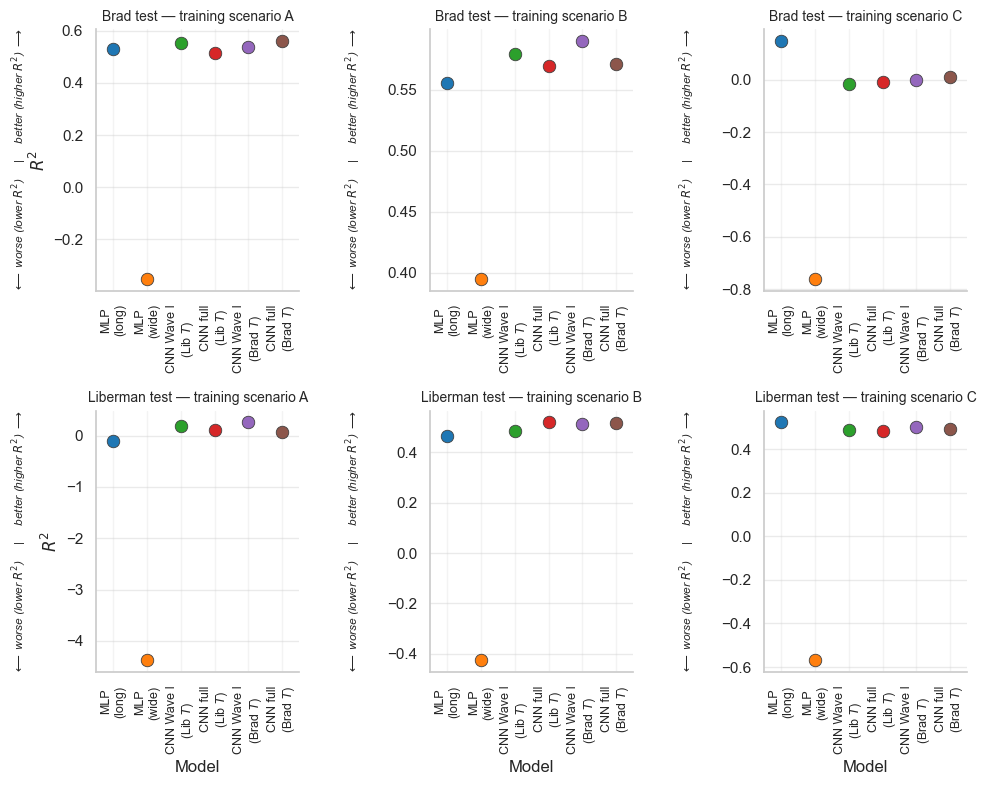

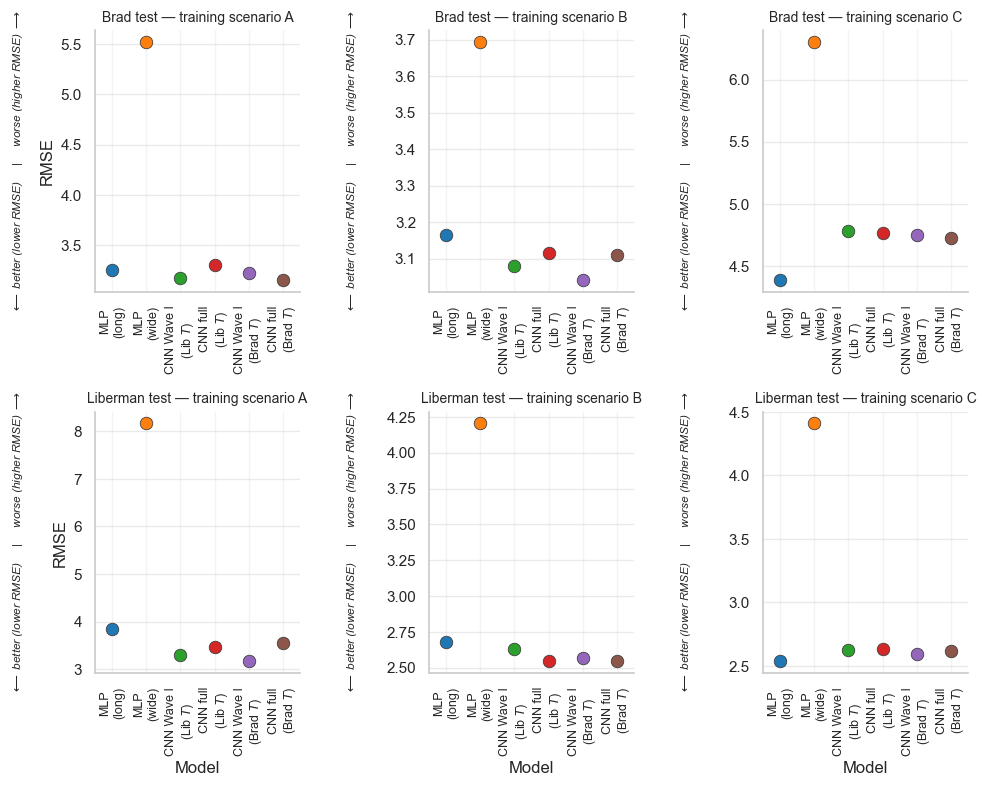

In [12]:
scenario_order = ["A", "B", "C"]
model_order = [
    "MLP",
    "MLP_wide",
    "CNN_WaveI_LibT",
    "CNN_full_LibT",
    "CNN_WaveI_BradT",
    "CNN_full_BradT",
]
model_labels = {
    "MLP": "MLP\n(long)",
    "MLP_wide": "MLP\n(wide)",
    "CNN_WaveI_LibT": "CNN Wave I\n(Lib $T$)",
    "CNN_full_LibT": "CNN full\n(Lib $T$)",
    "CNN_WaveI_BradT": "CNN Wave I\n(Brad $T$)",
    "CNN_full_BradT": "CNN full\n(Brad $T$)",
}
_disp_order = [model_labels[m] for m in model_order]
_model_colors = sns.color_palette("tab10", n_colors=len(model_order))
test_order = ["Brad", "Liberman"]


def _metric_point_figure(metric_col: str, y_label: str, better_text: str) -> None:
    """2×3 grid: rows = test cohort; cols = training scenario. x = model (independent y per panel)."""
    fig, axes = plt.subplots(2, 3, figsize=(12, 9), sharey=False, sharex=False)
    dfp = metrics_all[metrics_all["model"].isin(model_order)].copy()
    dfp["model_disp"] = pd.Categorical(
        dfp["model"].map(model_labels),
        categories=_disp_order,
        ordered=True,
    )
    for row, tname in enumerate(test_order):
        for col, scen in enumerate(scenario_order):
            ax = axes[row, col]
            sub = dfp[(dfp["test_set"] == tname) & (dfp["scenario"] == scen)]
            sns.stripplot(
                data=sub,
                x="model_disp",
                y=metric_col,
                order=_disp_order,
                hue="model_disp",
                hue_order=_disp_order,
                palette=_model_colors,
                jitter=False,
                dodge=False,
                size=9,
                linewidth=0.6,
                edgecolor="0.25",
                legend=False,
                ax=ax,
            )
            ax.set_xticks(np.arange(len(_disp_order)))
            ax.set_xticklabels(_disp_order, rotation=90, ha="center", fontsize=9)
            ax.tick_params(axis="x", labelbottom=True)
            ax.set_xlabel("Model" if row == len(test_order) - 1 else "")
            ax.set_title(f"{tname} test — training scenario {scen}", fontsize=10)
            ax.grid(True, axis="y", alpha=0.4)
            ax.grid(True, axis="x", alpha=0.22)
            sns.despine(ax=ax, top=True, right=True)
            ax.set_ylabel(y_label if col == 0 else "")
            ax.text(
                -0.38,
                0.5,
                better_text,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=8.5,
                style="italic",
                clip_on=False,
            )
    fig.tight_layout(rect=[0.14, 0.08, 0.99, 0.97])
    plt.show()


_metric_point_figure(
    "R2",
    r"$R^2$",
    r"$\longleftarrow$ worse (lower $R^2$)     |     better (higher $R^2$) $\longrightarrow$",
)
_metric_point_figure(
    "RMSE",
    "RMSE",
    r"$\longleftarrow$ better (lower RMSE)     |     worse (higher RMSE) $\longrightarrow$",
)

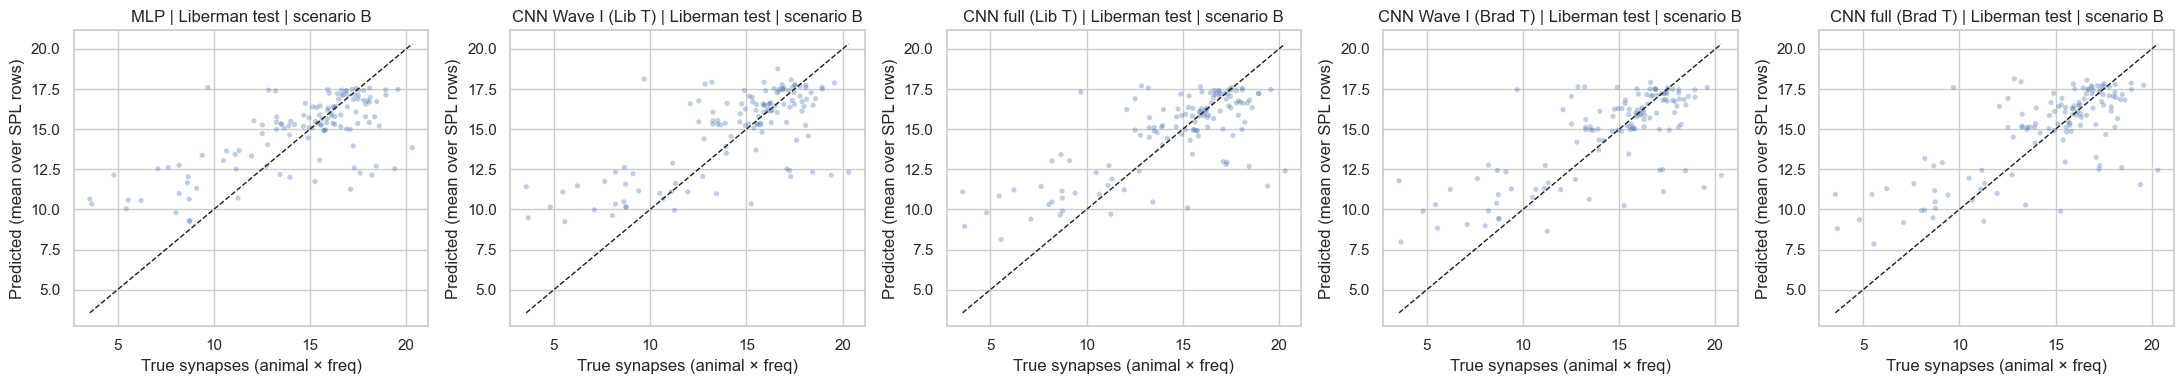

In [13]:
SCEN = "B"
TEST = "Liberman"

if TEST == "Brad":
    mlp_agg = mlp_bb[SCEN][2]
    aggs = [
        mlp_agg,
        cnn_wave_libT_bb[SCEN][2],
        cnn_full_libT_bb[SCEN][2],
        cnn_wave_bradT_bb[SCEN][2],
        cnn_full_bradT_bb[SCEN][2],
    ]
else:
    mlp_agg = mlp_lib[SCEN][2]
    aggs = [
        mlp_agg,
        cnn_wave_libT_lib[SCEN][2],
        cnn_full_libT_lib[SCEN][2],
        cnn_wave_bradT_lib[SCEN][2],
        cnn_full_bradT_lib[SCEN][2],
    ]

names = [
    "MLP",
    "CNN Wave I (Lib T)",
    "CNN full (Lib T)",
    "CNN Wave I (Brad T)",
    "CNN full (Brad T)",
]
fig, ax = plt.subplots(1, 5, figsize=(22, 4))
for a, df, name in zip(ax, aggs, names):
    a.scatter(df["y_true"], df["y_pred"], alpha=0.35, s=14, edgecolors="none")
    lo = float(min(df["y_true"].min(), df["y_pred"].min()))
    hi = float(max(df["y_true"].max(), df["y_pred"].max()))
    a.plot([lo, hi], [lo, hi], "k--", lw=1)
    a.set_xlabel("True synapses (animal × freq)")
    a.set_ylabel("Predicted (mean over SPL rows)")
    a.set_title(f"{name} | {TEST} test | scenario {SCEN}")
plt.tight_layout()
plt.show()

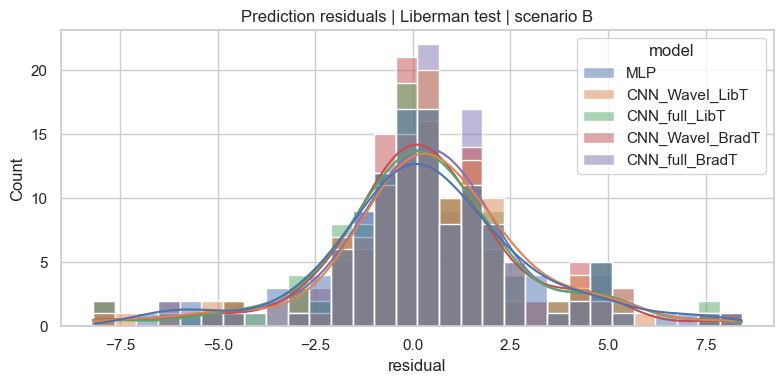

In [14]:
SCEN = "B"
TEST = "Liberman"
if TEST == "Brad":
    plot_df = pd.concat(
        [
            mlp_bb[SCEN][2].assign(model="MLP"),
            cnn_wave_libT_bb[SCEN][2].assign(model="CNN_WaveI_LibT"),
            cnn_full_libT_bb[SCEN][2].assign(model="CNN_full_LibT"),
            cnn_wave_bradT_bb[SCEN][2].assign(model="CNN_WaveI_BradT"),
            cnn_full_bradT_bb[SCEN][2].assign(model="CNN_full_BradT"),
        ],
        ignore_index=True,
    )
else:
    plot_df = pd.concat(
        [
            mlp_lib[SCEN][2].assign(model="MLP"),
            cnn_wave_libT_lib[SCEN][2].assign(model="CNN_WaveI_LibT"),
            cnn_full_libT_lib[SCEN][2].assign(model="CNN_full_LibT"),
            cnn_wave_bradT_lib[SCEN][2].assign(model="CNN_WaveI_BradT"),
            cnn_full_bradT_lib[SCEN][2].assign(model="CNN_full_BradT"),
        ],
        ignore_index=True,
    )
plot_df["residual"] = plot_df["y_pred"] - plot_df["y_true"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=plot_df, x="residual", hue="model", kde=True, ax=ax, bins=30)
ax.set_title(f"Prediction residuals | {TEST} test | scenario {SCEN}")
plt.tight_layout()
plt.show()

### Unified Wave I windows (30 samples on 0–8 ms grid)

Same pipeline as training: crop 0–8 ms, resample to **T** = `full_wave_target_len_lib` or `full_wave_target_len_brad`, then 30 samples centred at `p1_latency`.

### Full-wave 0–8 ms (same **T**)

Brad: time from `x` (ms). Liberman: `full_waveform` / `Waveform` with 0–17 ms timebase before crop.

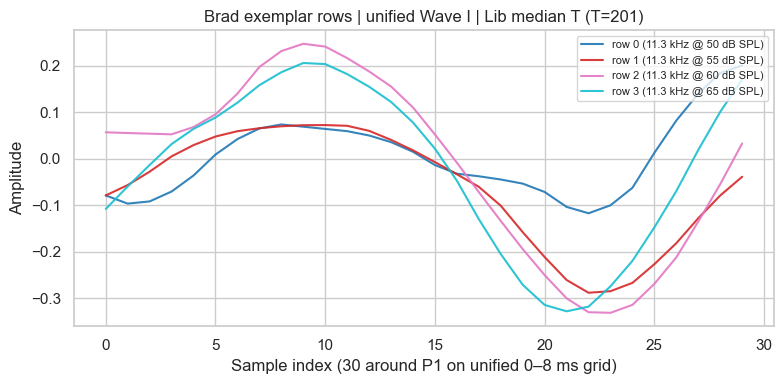

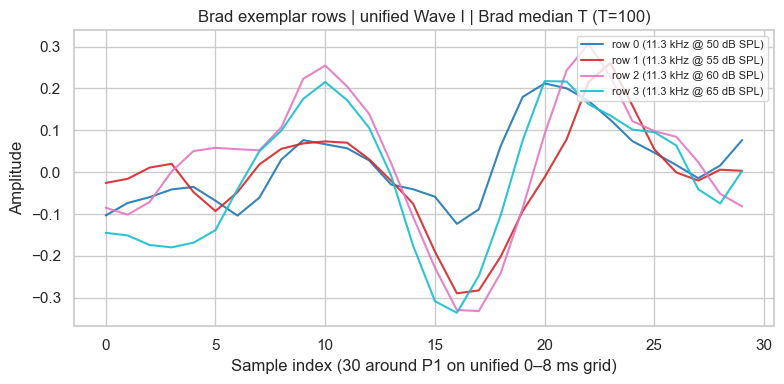

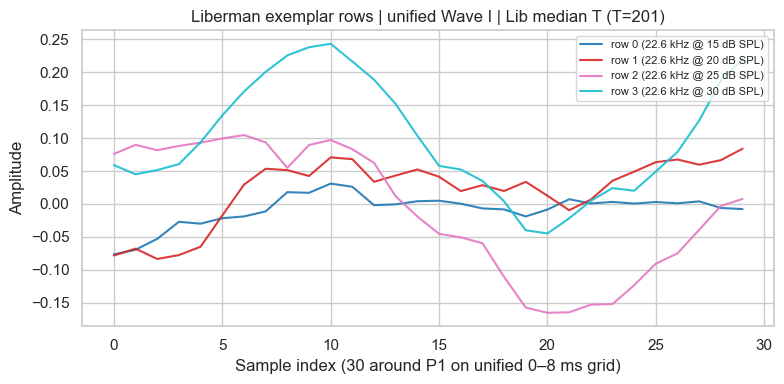

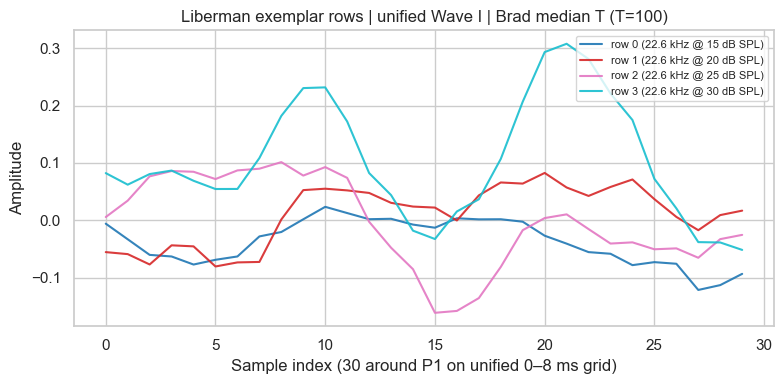

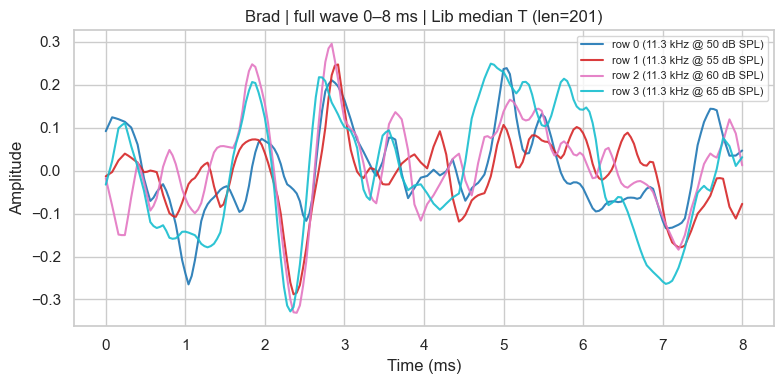

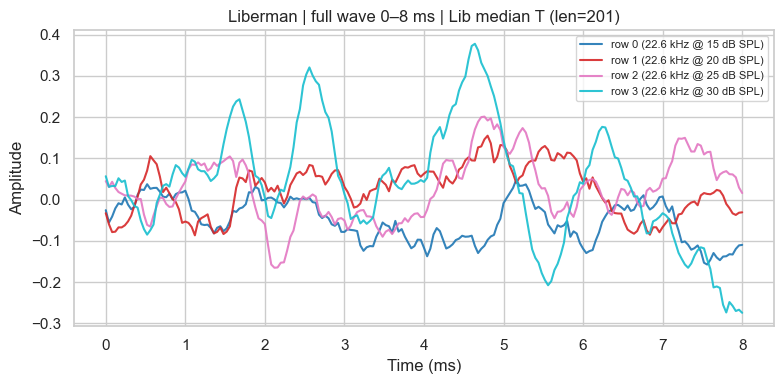

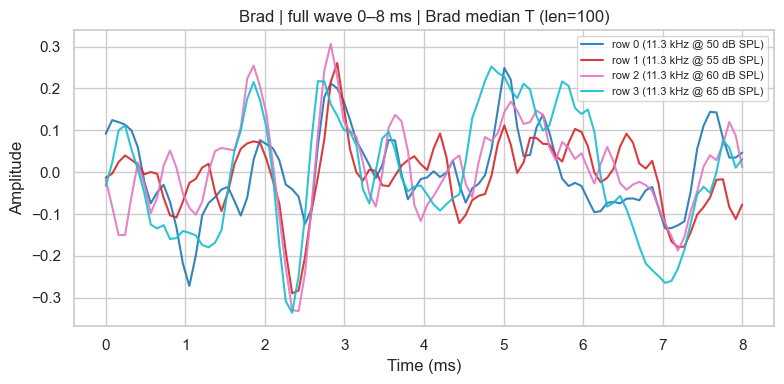

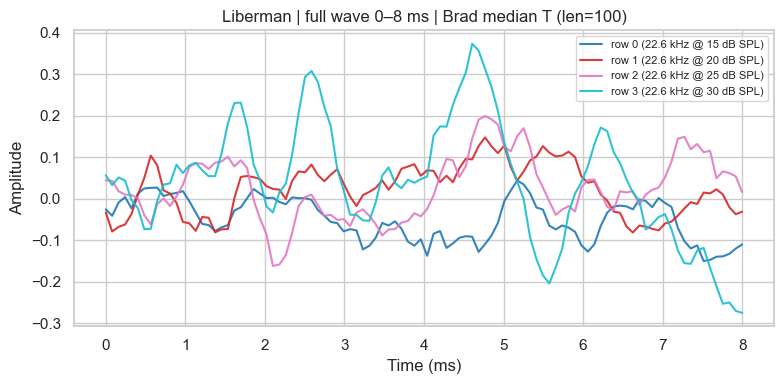

In [15]:
n_show = 4


# Use train+test long rows so we always have enough exemplars (test-only can be tiny).
# Dedupe by (animal, frequency, level) so curves are not accidental repeats.
def _pick_wave_demo_rows(train_df, test_df, full_df, n):
    pool = pd.concat([train_df, test_df], axis=0, ignore_index=True).drop_duplicates(
        subset=["animal_id", "frequency", "level"], keep="first"
    )
    if len(pool) >= n:
        return pool.iloc[:n]
    if len(test_df) >= n:
        return test_df.iloc[:n]
    if len(full_df) >= n:
        return full_df.drop_duplicates(
            subset=["animal_id", "frequency", "level"], keep="first"
        ).iloc[:n]
    return pool.iloc[: min(n, len(pool))]


def _wave_legend_label(i, row) -> str:
    fq = float(row["frequency"])
    lv = float(row["level"])
    return f"row {i} ({fq:g} kHz @ {lv:g} dB SPL)"


bb_demo = _pick_wave_demo_rows(bb_lt, bb_lte, data.brad_buran_df, n_show)
lib_demo = _pick_wave_demo_rows(lib_lt, lib_lte, data.orig_lib, n_show)
idx_bb = bb_demo.index
idx_lib = lib_demo.index
tw_lib = int(data.full_wave_target_len_lib)
tw_brad = int(data.full_wave_target_len_brad)
t30 = np.arange(30)
_colors = plt.cm.tab10(np.linspace(0, 0.9, max(n_show, 4)))

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    W_bb = unified_grid_wave_i_matrix(bb_demo, idx_bb, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(W_bb.shape[0]):
        row = bb_demo.iloc[i]
        ax.plot(
            t30,
            W_bb[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Sample index (30 around P1 on unified 0–8 ms grid)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Brad exemplar rows | unified Wave I | {tag} (T={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    W_lib = unified_grid_wave_i_matrix(lib_demo, idx_lib, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(W_lib.shape[0]):
        row = lib_demo.iloc[i]
        ax.plot(
            t30,
            W_lib[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Sample index (30 around P1 on unified 0–8 ms grid)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Liberman exemplar rows | unified Wave I | {tag} (T={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    t_ms = np.linspace(FULL_WAVE_WINDOW_MS[0], FULL_WAVE_WINDOW_MS[1], tw)
    F_bb = full_wave_matrix(bb_demo, idx_bb, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(F_bb.shape[0]):
        row = bb_demo.iloc[i]
        ax.plot(
            t_ms,
            F_bb[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Brad | full wave 0–8 ms | {tag} (len={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

    F_lib = full_wave_matrix(lib_demo, idx_lib, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(F_lib.shape[0]):
        row = lib_demo.iloc[i]
        ax.plot(
            t_ms,
            F_lib[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Liberman | full wave 0–8 ms | {tag} (len={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()